In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt

import sys, os
sys.path.append("../../src/")

from network import FeedForward


In [2]:
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [3]:
seed = 1
network = FeedForward(init_steps = 300, seed=seed)

POs = network.get_POs_over_trials(network.w_ef_baseline, network.n_steps, 'baseline')
drift_mag_baseline, drift_rate_baseline, convergence_baseline = network.get_metrics(network.N, network.n_days, network.theta_stim, network.POs)

network_inh = FeedForward(init_steps = 300, seed=seed, inh="on")
POs_inh = network_inh.get_POs_over_trials(network_inh.w_ef_baseline, network_inh.n_steps, 'baseline')
drift_mag_inh, drift_rate_inh, convergence_inh = network_inh.get_metrics(network_inh.N, network_inh.n_days, network_inh.theta_stim, network_inh.POs)


setting seed: 1


100%|██████████| 840/840 [00:13<00:00, 63.11it/s]


setting seed: 1


100%|██████████| 840/840 [00:12<00:00, 64.92it/s]


In [4]:
corrs_initial = network.get_correlations(network.W[:, :, 0])
corrs_final = network.get_correlations(network.W[:, :, -1])

corrs_initial_inh = network_inh.get_correlations(network_inh.W[:, :, 0])
corrs_final_inh = network_inh.get_correlations(network_inh.W[:, :, -1])

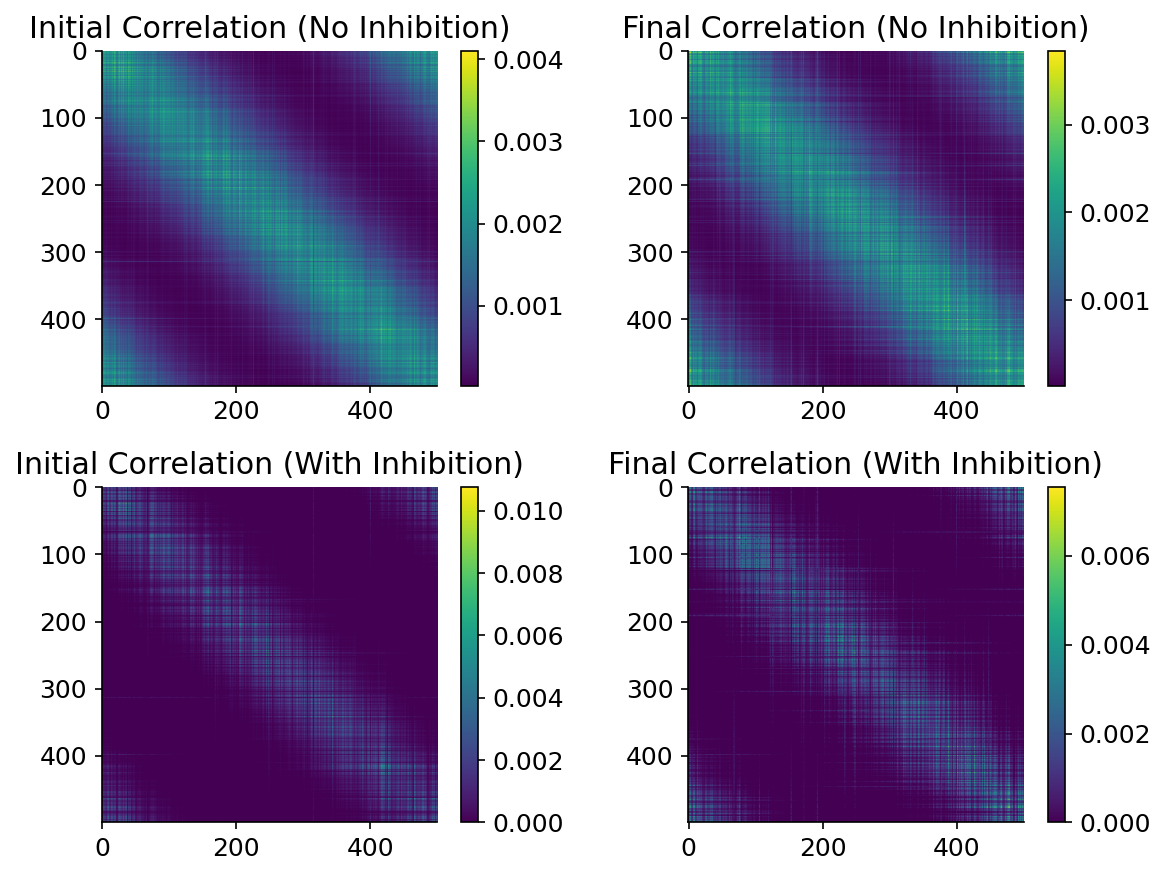

In [8]:
corr_across_stim_initial = np.mean(corrs_initial, axis=2)
corr_across_stim_final = np.mean(corrs_final, axis=2)

corr_across_stim_initial_inh = np.mean(corrs_initial_inh, axis=2)
corr_across_stim_final_inh = np.mean(corrs_final_inh, axis=2)

fig, axs = plt.subplots(2, 2, figsize=(8, 6))

im1 = axs[0, 0].imshow(corr_across_stim_initial, cmap='viridis')
axs[0, 0].set_title("Initial Correlation (No Inhibition)")
plt.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(corr_across_stim_final, cmap='viridis')
axs[0, 1].set_title("Final Correlation (No Inhibition)")
plt.colorbar(im2, ax=axs[0, 1])

im3 = axs[1, 0].imshow(corr_across_stim_initial_inh, cmap='viridis')
axs[1, 0].set_title("Initial Correlation (With Inhibition)")
plt.colorbar(im3, ax=axs[1, 0])

im4 = axs[1, 1].imshow(corr_across_stim_final_inh, cmap='viridis')
axs[1, 1].set_title("Final Correlation (With Inhibition)")
plt.colorbar(im4, ax=axs[1, 1])

fig.tight_layout()
plt.show()

In [4]:
corrs_initial_new = network.get_correlations_new(network.W[:, :, 0])
corrs_final_new = network.get_correlations_new(network.W[:, :, -1])

corrs_initial_inh_new = network_inh.get_correlations_new(network_inh.W[:, :, 0])
corrs_final_inh_new = network_inh.get_correlations_new(network_inh.W[:, :, -1])

/Users/divyansh/miniforge3/envs/drift/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/divyansh/miniforge3/envs/drift/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


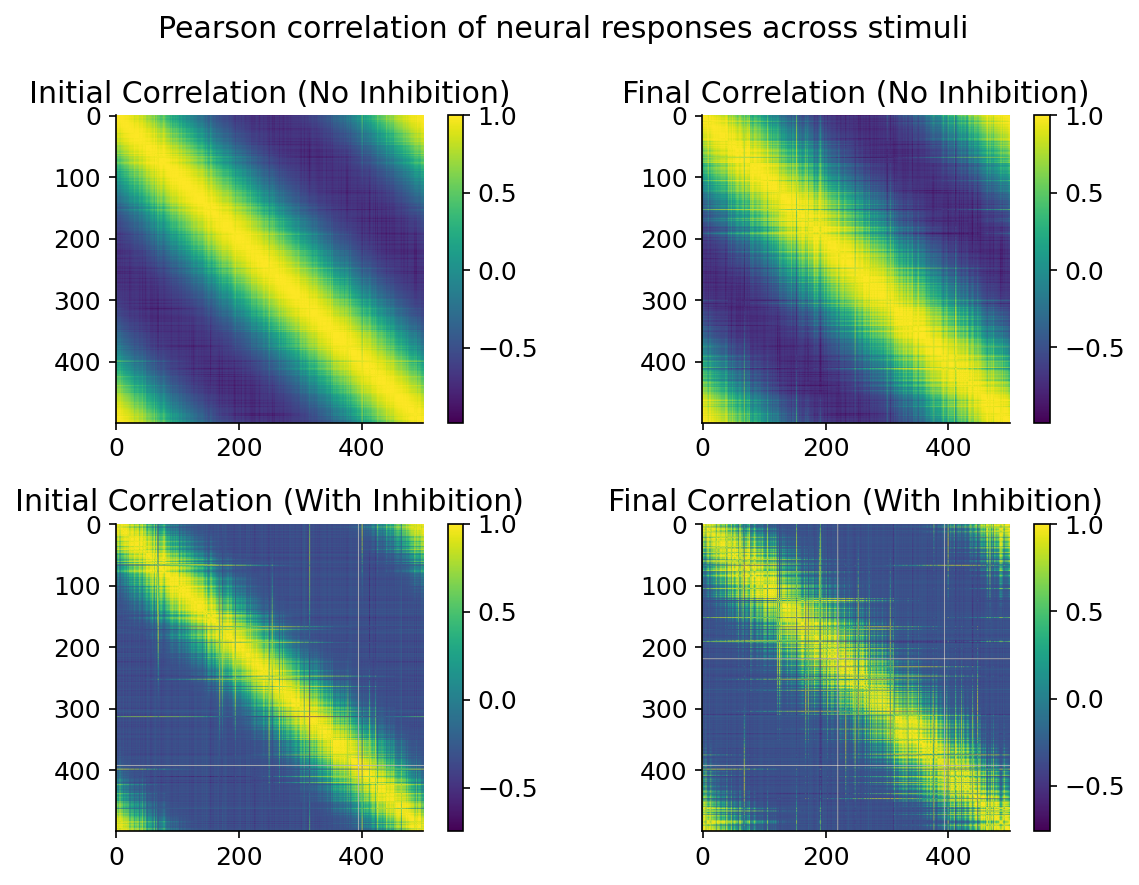

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

im1 = axs[0, 0].imshow(corrs_initial_new, cmap='viridis')
axs[0, 0].set_title("Initial Correlation (No Inhibition)")
plt.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(corrs_final_new, cmap='viridis')
axs[0, 1].set_title("Final Correlation (No Inhibition)")
plt.colorbar(im2, ax=axs[0, 1])

im3 = axs[1, 0].imshow(corrs_initial_inh_new, cmap='viridis')
axs[1, 0].set_title("Initial Correlation (With Inhibition)")
plt.colorbar(im3, ax=axs[1, 0])

im4 = axs[1, 1].imshow(corrs_final_inh_new, cmap='viridis')
axs[1, 1].set_title("Final Correlation (With Inhibition)")
plt.colorbar(im4, ax=axs[1, 1])

fig.suptitle("Pearson correlation of neural responses across stimuli")
fig.tight_layout()

plt.show()



In [ ]:
corrs_initial_inh_upper_triangle = corrs_initial_inh_new[np.triu_indices_from(corrs_initial_inh_new, k=1)]


np.float64(nan)

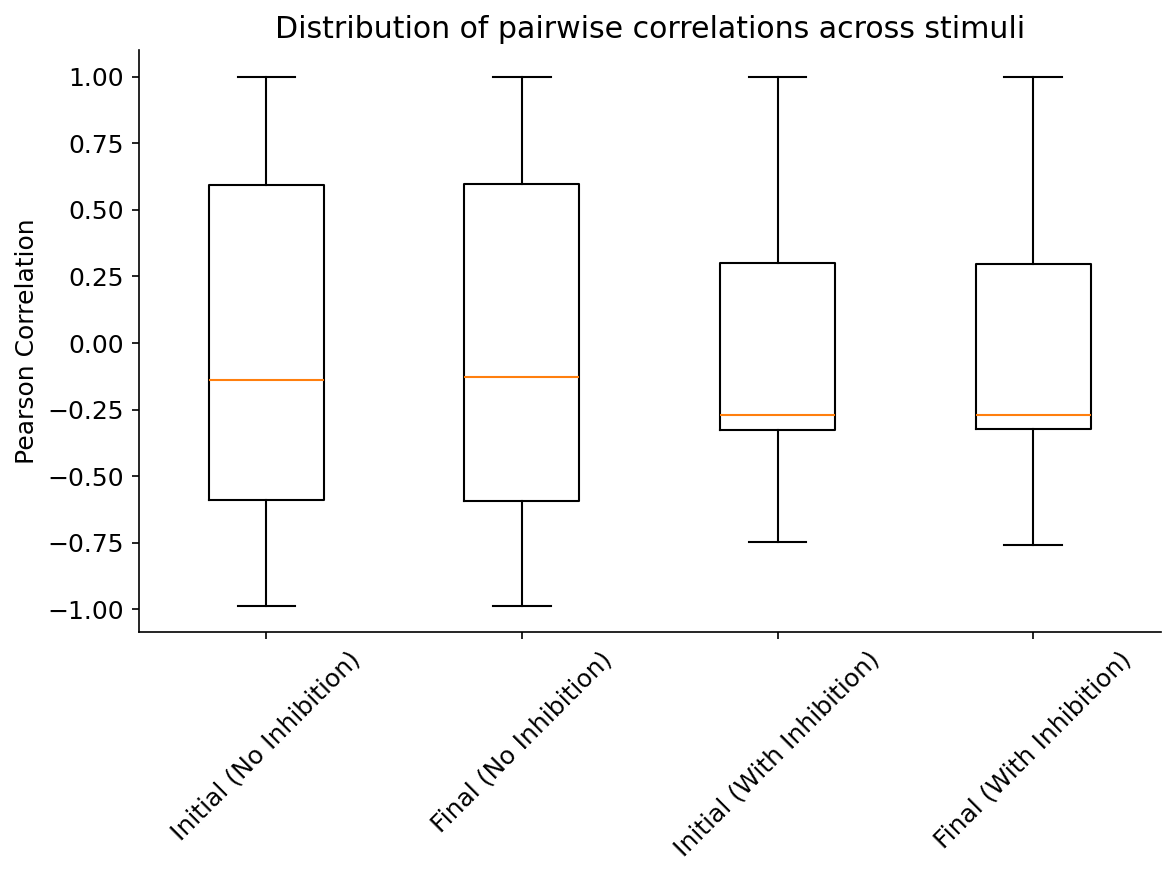

In [55]:
# remove nan values
corrs_initial_new_upper_triangle = corrs_initial_new[np.triu_indices_from(corrs_initial_new, k=1)]
corrs_initial_new_upper_triangle = corrs_initial_new_upper_triangle[~np.isnan(corrs_initial_new_upper_triangle)]
corrs_final_new_upper_triangle = corrs_final_new[np.triu_indices_from(corrs_final_new, k=1)]
corrs_final_new_upper_triangle = corrs_final_new_upper_triangle[~np.isnan(corrs_final_new_upper_triangle)]

corrs_initial_inh_new_upper_triangle = corrs_initial_inh_new[np.triu_indices_from(corrs_initial_inh_new, k=1)]
corrs_initial_inh_new_upper_triangle = corrs_initial_inh_new_upper_triangle[~np.isnan(corrs_initial_inh_new_upper_triangle)]
corrs_final_inh_new_upper_triangle = corrs_final_inh_new[np.triu_indices_from(corrs_final_inh_new, k=1)]
corrs_final_inh_new_upper_triangle = corrs_final_inh_new_upper_triangle[~np.isnan(corrs_final_inh_new_upper_triangle)]

# make bar plot
labels = ['Initial (No Inhibition)', 'Final (No Inhibition)', 'Initial (With Inhibition)', 'Final (With Inhibition)']
data = [corrs_initial_new_upper_triangle, corrs_final_new_upper_triangle, corrs_initial_inh_new_upper_triangle, corrs_final_inh_new_upper_triangle]

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(data, tick_labels=labels)
ax.set_title("Distribution of pairwise correlations across stimuli")
ax.set_ylabel("Pearson Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
print(f"Avg pairwise correlation (No Inhibition) =", corrs_initial_new_upper_triangle.mean())
print(f"Avg pairwise correlation (with inh) =", corrs_initial_inh_new_upper_triangle.mean())



Avg pairwise correlation (No Inhibition) = -0.001983813448357522
Avg pairwise correlation (with inh) = -0.0018048306003493272


Text(0.5, 1.0, 'Average pairwise correlation across stimuli')

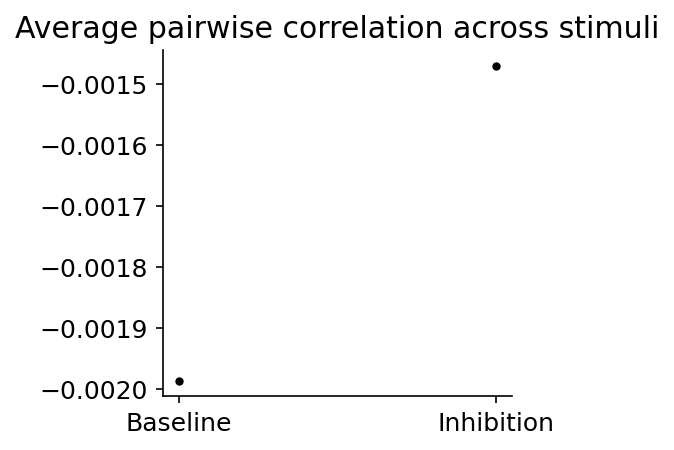

In [42]:
# plot bar of avg correlation only
corr_initial_mean = np.mean(corrs_initial_new_upper_triangle)
corr_final_mean = np.mean(corrs_final_new_upper_triangle)
corr_initial_inh_mean = np.mean(corrs_initial_inh_upper_triangle)
corr_final_inh_mean = np.mean(corrs_final_inh_upper_triangle)

labels = ['Baseline', 'Inhibition']

plt.figure(figsize=(3, 3))
plt.plot([0, 1], [corr_final_mean, corr_final_inh_mean], '.k')
plt.xticks([0, 1], labels)
plt.title("Average pairwise correlation across stimuli")

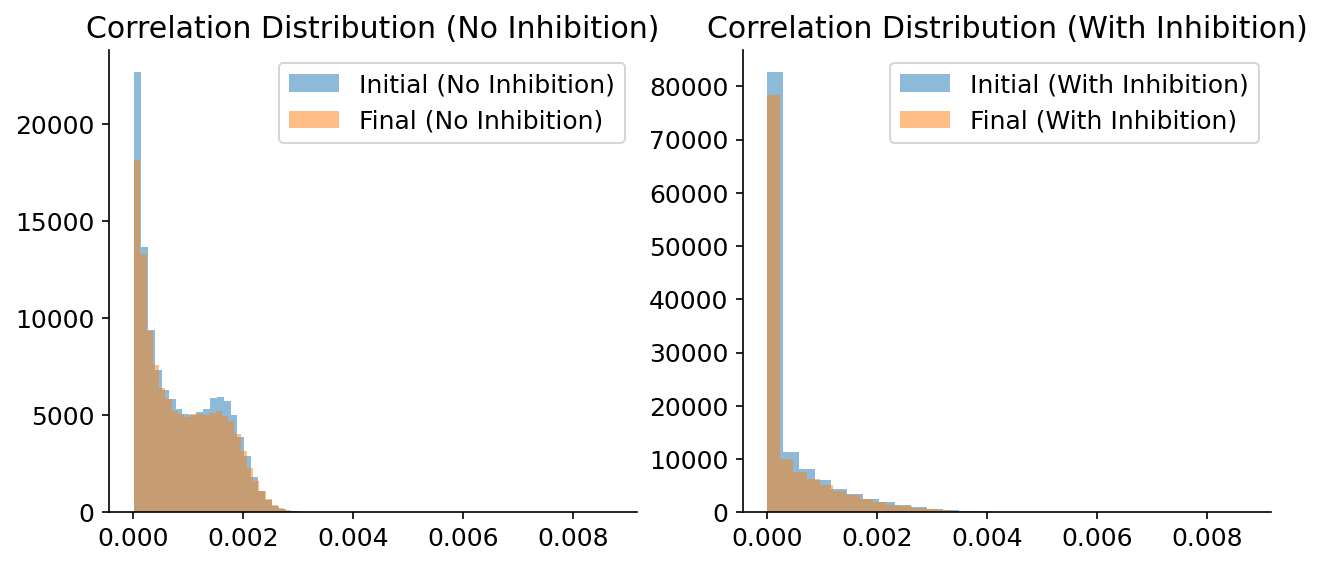

In [13]:
# get upper triangular values of the correlation matrices
corr_across_stim_initial_upper = corr_across_stim_initial[np.triu_indices(network.N, k=1)]
corr_across_stim_final_upper = corr_across_stim_final[np.triu_indices(network.N, k=1)]
corr_across_stim_initial_inh_upper = corr_across_stim_initial_inh[np.triu_indices(network.N, k=1)]
corr_across_stim_final_inh_upper = corr_across_stim_final_inh[np.triu_indices(network.N, k=1)]

# plot histograms of the upper triangular values
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axs[0].hist(corr_across_stim_initial_upper, bins=30, alpha=0.5, label='Initial (No Inhibition)')
axs[0].hist(corr_across_stim_final_upper, bins=30, alpha=0.5, label='Final (No Inhibition)')
axs[0].set_title("Correlation Distribution (No Inhibition)")
axs[0].legend()

axs[1].hist(corr_across_stim_initial_inh_upper, bins=30, alpha=0.5, label='Initial (With Inhibition)')
axs[1].hist(corr_across_stim_final_inh_upper, bins=30, alpha=0.5, label='Final (With Inhibition)')
axs[1].set_title("Correlation Distribution (With Inhibition)")
axs[1].legend() 


### Three levels of inhibition

In [49]:
inh_1_scale = 0.3
inh_2_scale = 0.7
inh_3_scale = 1.0

seed = 1

network_inh_1 = FeedForward(init_steps = 300, seed=seed, inh="on", inh_type='co-tuned', inh_scale=inh_1_scale)
POs_inh_1 = network_inh_1.get_POs_over_trials(network_inh_1.w_ef_baseline, network_inh_1.n_steps, 'baseline')
drift_mag_inh_1, drift_rate_inh_1, convergence_inh_1 = network_inh_1.get_metrics(network_inh_1.N, network_inh_1.n_days, network_inh_1.theta_stim, network_inh_1.POs)

network_inh_2 = FeedForward(init_steps = 300, seed=seed, inh="on", inh_type='co-tuned', inh_scale=inh_2_scale)
POs_inh_2 = network_inh_2.get_POs_over_trials(network_inh_2.w_ef_baseline, network_inh_2.n_steps, 'baseline')
drift_mag_inh_2, drift_rate_inh_2, convergence_inh_2 = network_inh_2.get_metrics(network_inh_2.N, network_inh_2.n_days, network_inh_2.theta_stim, network_inh_2.POs)

network_inh_3 = FeedForward(init_steps = 300, seed=seed, inh="on", inh_type='co-tuned', inh_scale=inh_3_scale)
POs_inh_3 = network_inh_3.get_POs_over_trials(network_inh_3.w_ef_baseline, network_inh_3.n_steps, 'baseline')
drift_mag_inh_3, drift_rate_inh_3, convergence_inh_3 = network_inh_3.get_metrics(network_inh_3.N, network_inh_3.n_days, network_inh_3.theta_stim, network_inh_3.POs)


setting seed: 1


100%|██████████| 840/840 [00:10<00:00, 77.89it/s]


setting seed: 1


100%|██████████| 840/840 [00:12<00:00, 66.05it/s]


setting seed: 1


100%|██████████| 840/840 [00:11<00:00, 70.74it/s]


In [81]:
corrs_initial_inh_1 = network_inh_1.get_correlations(network_inh_1.W[:, :, 0])
corrs_final_inh_1 = network_inh_1.get_correlations(network_inh_1.W[:, :, -1])

corrs_initial_inh_2 = network_inh_2.get_correlations(network_inh_2.W[:, :, 0])
corrs_final_inh_2 = network_inh_2.get_correlations(network_inh_2.W[:, :, -1])

corrs_initial_inh_3 = network_inh_3.get_correlations(network_inh_3.W[:, :, 0])
corrs_final_inh_3 = network_inh_3.get_correlations(network_inh_3.W[:, :, -1])


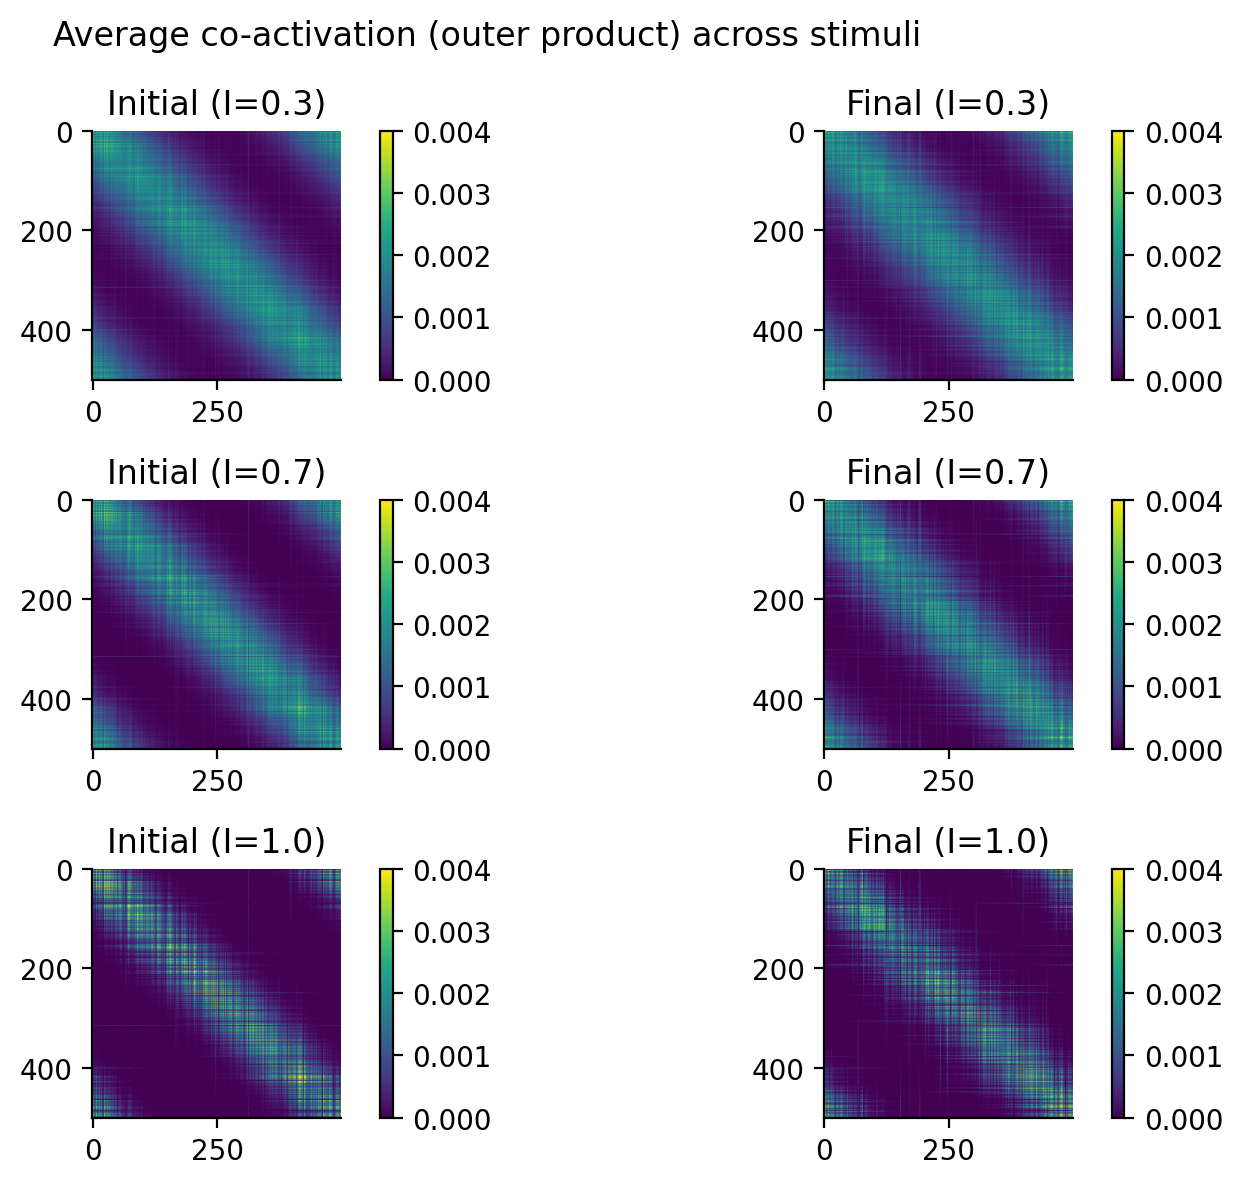

In [90]:
# imshow the correlation matrices for the three different inhibition scales


fig, axs = plt.subplots(3, 2, figsize=(8, 6), dpi=200)

vmax = 0.004
vmin = 0
im1 = axs[0, 0].imshow(np.mean(corrs_initial_inh_1, axis=2), cmap='viridis', vmax=vmax, vmin=vmin)
axs[0, 0].set_title(f"Initial (I={inh_1_scale})")
plt.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(np.mean(corrs_final_inh_1, axis=2), cmap='viridis', vmax=vmax, vmin=vmin)
axs[0, 1].set_title(f"Final (I={inh_1_scale})")
plt.colorbar(im2, ax=axs[0, 1])

im3 = axs[1, 0].imshow(np.mean(corrs_initial_inh_2, axis=2), cmap='viridis', vmax=vmax, vmin=vmin)
axs[1, 0].set_title(f"Initial (I={inh_2_scale})")
plt.colorbar(im3, ax=axs[1, 0])

im4 = axs[1, 1].imshow(np.mean(corrs_final_inh_2, axis=2), cmap='viridis', vmax=vmax, vmin=vmin)
axs[1, 1].set_title(f"Final (I={inh_2_scale})")
plt.colorbar(im4, ax=axs[1, 1])

im5 = axs[2, 0].imshow(np.mean(corrs_initial_inh_3, axis=2), cmap='viridis', vmax=vmax, vmin=vmin)
axs[2, 0].set_title(f"Initial (I={inh_3_scale})")
plt.colorbar(im5, ax=axs[2, 0])

im6 = axs[2, 1].imshow(np.mean(corrs_final_inh_3, axis=2), cmap='viridis', vmax=vmax, vmin=vmin)
axs[2, 1].set_title(f"Final (I={inh_3_scale})")
plt.colorbar(im6, ax=axs[2, 1])

fig.suptitle("Average co-activation (outer product) across stimuli")
fig.tight_layout()
plt.show()

In [93]:
corrs_initial_inh_1.shape

(500, 500, 100)

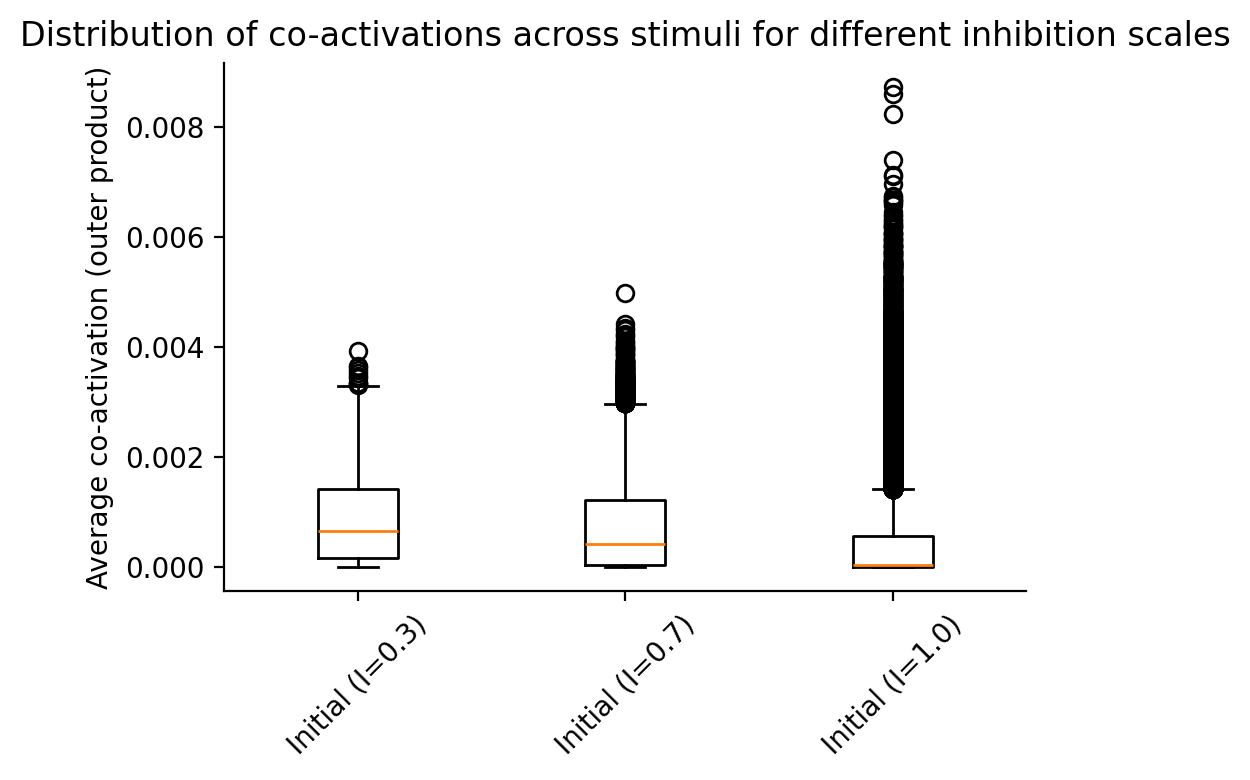

In [97]:
corrs_initial_inh_1_avg = np.mean(corrs_initial_inh_1, axis=2)
corrs_initial_inh_2_avg = np.mean(corrs_initial_inh_2, axis=2)
corrs_initial_inh_3_avg = np.mean(corrs_initial_inh_3, axis=2)

corrs_initial_inh_1_upper_triangle = corrs_initial_inh_1_avg[np.triu_indices_from(corrs_initial_inh_1_avg, k=1)]
corrs_initial_inh_2_upper_triangle = corrs_initial_inh_2_avg[np.triu_indices_from(corrs_initial_inh_2_avg, k=1)]
corrs_initial_inh_3_upper_triangle = corrs_initial_inh_3_avg[np.triu_indices_from(corrs_initial_inh_3_avg, k=1)]

# box plot 
labels = [f"Initial (I={inh_1_scale})", f"Initial (I={inh_2_scale})", f"Initial (I={inh_3_scale})"]
data = [corrs_initial_inh_1_upper_triangle, corrs_initial_inh_2_upper_triangle, corrs_initial_inh_3_upper_triangle]
fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
ax.boxplot(data, tick_labels=labels)
ax.set_title("Distribution of co-activations across stimuli for different inhibition scales")
ax.set_ylabel("Average co-activation (outer product)")
plt.xticks(rotation=45)
plt.tight_layout()

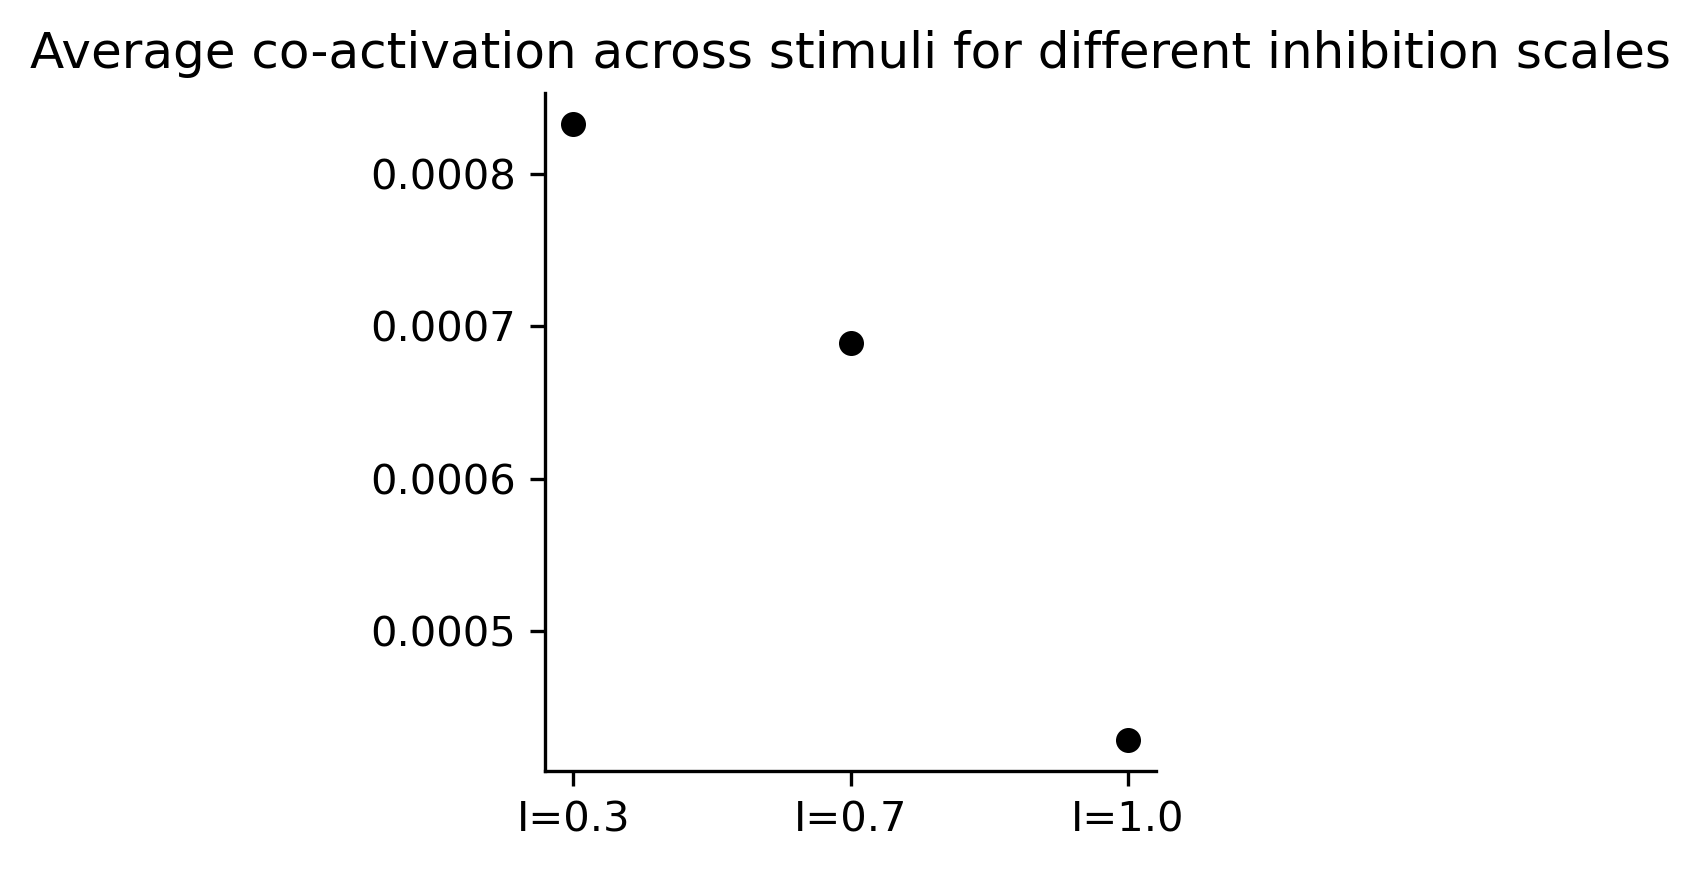

In [116]:
# bar plot of averages
avg_inh_1 = corrs_initial_inh_1_upper_triangle.mean()
avg_inh_2 = corrs_initial_inh_2_upper_triangle.mean()
avg_inh_3 = corrs_initial_inh_3_upper_triangle.mean()

labels = [f"I={inh_1_scale}", f"I={inh_2_scale}", f"I={inh_3_scale}"]
averages = [avg_inh_1, avg_inh_2, avg_inh_3]
plt.figure(figsize=(3, 3), dpi=300)
plt.plot([0, 1, 2], averages,'.k', ms=10)
plt.xticks([0, 1, 2], labels)
plt.title("Average co-activation across stimuli for different inhibition scales")
plt.tight_layout()
plt.show()

In [47]:
corrs_initial_inh_1_new = network_inh_1.get_correlations_new(network_inh_1.W[:, :, 0])
corrs_final_inh_1_new = network_inh_1.get_correlations_new(network_inh_1.W[:, :, -1])

corrs_initial_inh_2_new = network_inh_2.get_correlations_new(network_inh_2.W[:, :, 0])
corrs_final_inh_2_new = network_inh_2.get_correlations_new(network_inh_2.W[:, :, -1])

corrs_initial_inh_3_new = network_inh_3.get_correlations_new(network_inh_3.W[:, :, 0])
corrs_final_inh_3_new = network_inh_3.get_correlations_new(network_inh_3.W[:, :, -1])


/Users/divyansh/miniforge3/envs/drift/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/divyansh/miniforge3/envs/drift/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


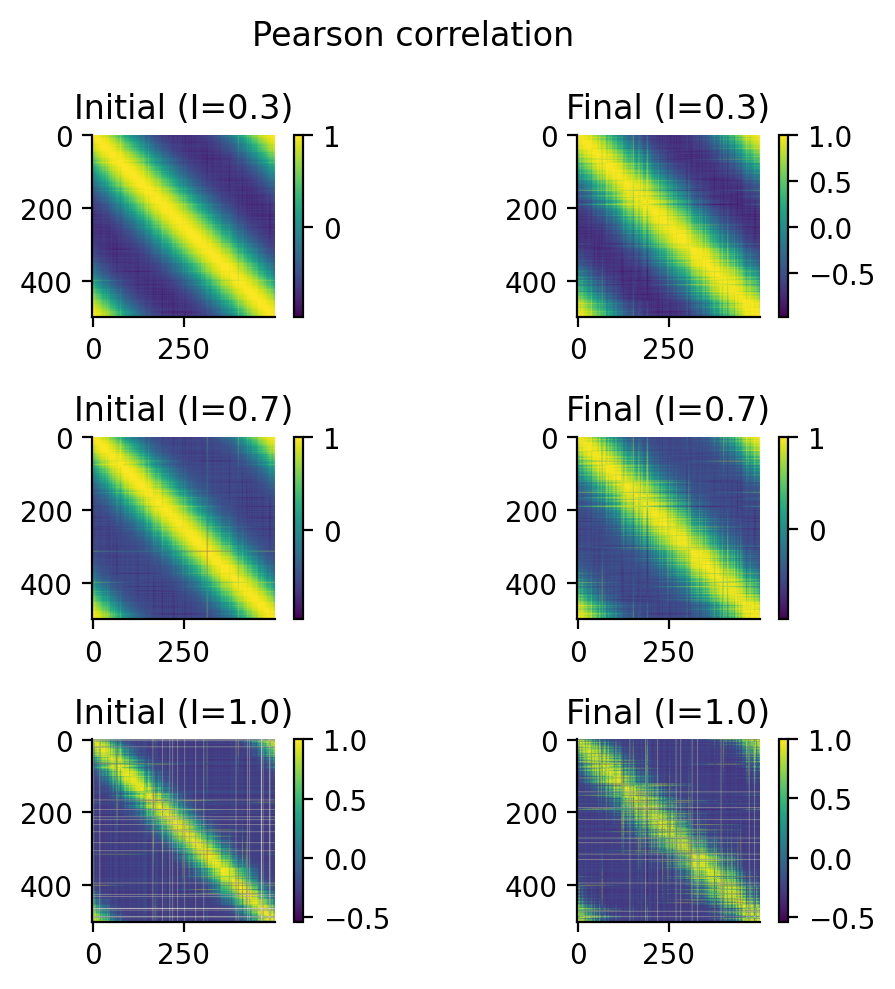

In [67]:
plt.rcParams['font.size'] = 10
fig, axs = plt.subplots(3, 2, figsize=(5, 5), dpi=200)

im1 = axs[0, 0].imshow(corrs_initial_inh_1_new, cmap='viridis')
axs[0, 0].set_title(f"Initial (I={inh_1_scale})")
plt.colorbar(im1, ax=axs[0, 0])

im2 = axs[0, 1].imshow(corrs_final_inh_1_new, cmap='viridis')
axs[0, 1].set_title(f"Final (I={inh_1_scale})")
plt.colorbar(im2, ax=axs[0, 1]) 

im3 = axs[1, 0].imshow(corrs_initial_inh_2_new, cmap='viridis')
axs[1, 0].set_title(f"Initial (I={inh_2_scale})")
plt.colorbar(im3, ax=axs[1, 0])

im4 = axs[1, 1].imshow(corrs_final_inh_2_new, cmap='viridis')
axs[1, 1].set_title(f"Final (I={inh_2_scale})")
plt.colorbar(im4, ax=axs[1, 1])

im5 = axs[2, 0].imshow(corrs_initial_inh_3_new, cmap='viridis')
axs[2, 0].set_title(f"Initial (I={inh_3_scale})")
plt.colorbar(im5, ax=axs[2, 0])

im6 = axs[2, 1].imshow(corrs_final_inh_3_new, cmap='viridis')
axs[2, 1].set_title(f"Final (I={inh_3_scale})")
plt.colorbar(im6, ax=axs[2, 1])

fig.suptitle("Pearson correlation")
fig.tight_layout()
plt.show()

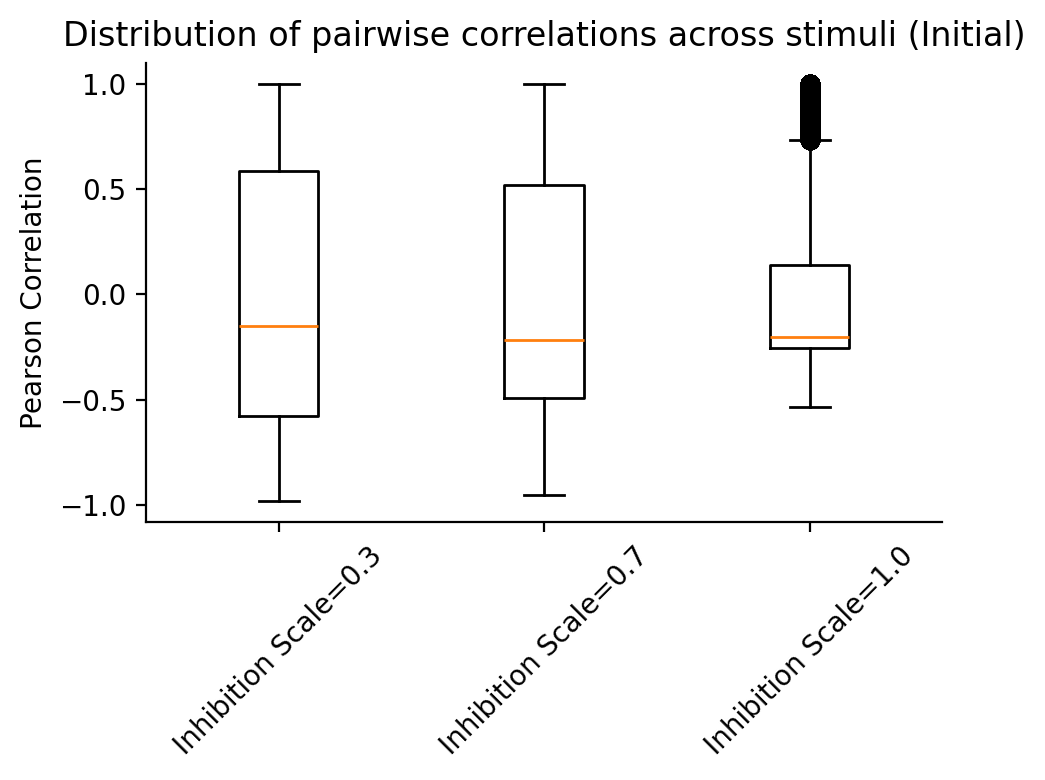

In [74]:
corrs_initial_inh_1_new_upper_triangle = corrs_initial_inh_1_new[np.triu_indices_from(corrs_initial_inh_1_new, k=1)]
corrs_initial_inh_1_new_upper_triangle = corrs_initial_inh_1_new_upper_triangle[~np.isnan(corrs_initial_inh_1_new_upper_triangle)]

corrs_initial_inh_2_new_upper_triangle = corrs_initial_inh_2_new[np.triu_indices_from(corrs_initial_inh_2_new, k=1)]
corrs_initial_inh_2_new_upper_triangle = corrs_initial_inh_2_new_upper_triangle[~np.isnan(corrs_initial_inh_2_new_upper_triangle)]  

corrs_initial_inh_3_new_upper_triangle = corrs_initial_inh_3_new[np.triu_indices_from(corrs_initial_inh_3_new, k=1)]
corrs_initial_inh_3_new_upper_triangle = corrs_initial_inh_3_new_upper_triangle[~np.isnan(corrs_initial_inh_3_new_upper_triangle)]  

# box plot
labels = [f'Inhibition Scale={inh_1_scale}', f'Inhibition Scale={inh_2_scale}', f'Inhibition Scale={inh_3_scale}']
data = [corrs_initial_inh_1_new_upper_triangle, corrs_initial_inh_2_new_upper_triangle, corrs_initial_inh_3_new_upper_triangle]
fig, ax = plt.subplots(figsize=(5, 4), dpi=200)
ax.boxplot(data, tick_labels=labels)
ax.set_title("Distribution of pairwise correlations across stimuli (Initial)")
ax.set_ylabel("Pearson Correlation")

# # overlay scatter points
# for i in range(len(data)):
#     y = data[i]
#     x = np.random.normal(i+1, 0.04, size=len(y))
#     plt.plot(x, y, 'r.', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()

In [54]:
print(f"Avg pairwise correlation I={inh_1_scale} =", corrs_initial_inh_1_new_upper_triangle.mean())
print(f"Avg pairwise correlation I={inh_2_scale} =", corrs_initial_inh_2_new_upper_triangle.mean())
print(f"Avg pairwise correlation I={inh_3_scale} =", corrs_initial_inh_3_new_upper_triangle.mean())

Avg pairwise correlation I=0.3 = -0.0019784846550582823
Avg pairwise correlation I=0.7 = -0.001963271346576425
Avg pairwise correlation I=1.0 = -0.001243394875912054


Avg POSITIVE correlation I=0.3: 0.6045 (n=55557 pairs)
Avg POSITIVE correlation I=0.7: 0.5956 (n=51744 pairs)
Avg POSITIVE correlation I=1.0: 0.5543 (n=33380 pairs)


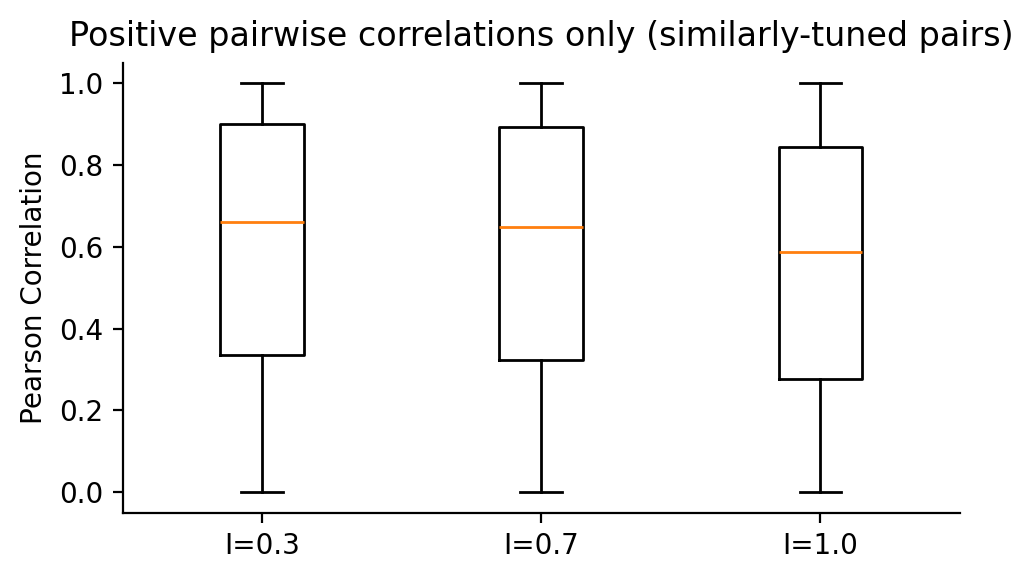

In [77]:
# Filter to positive correlations only
pos_corrs_inh_1 = corrs_initial_inh_1_new_upper_triangle[corrs_initial_inh_1_new_upper_triangle > 0]
pos_corrs_inh_2 = corrs_initial_inh_2_new_upper_triangle[corrs_initial_inh_2_new_upper_triangle > 0]
pos_corrs_inh_3 = corrs_initial_inh_3_new_upper_triangle[corrs_initial_inh_3_new_upper_triangle > 0]

print(f"Avg POSITIVE correlation I={inh_1_scale}: {pos_corrs_inh_1.mean():.4f} (n={len(pos_corrs_inh_1)} pairs)")
print(f"Avg POSITIVE correlation I={inh_2_scale}: {pos_corrs_inh_2.mean():.4f} (n={len(pos_corrs_inh_2)} pairs)")
print(f"Avg POSITIVE correlation I={inh_3_scale}: {pos_corrs_inh_3.mean():.4f} (n={len(pos_corrs_inh_3)} pairs)")

# Box plot of positive correlations
fig, ax = plt.subplots(figsize=(5, 3), dpi=200)
data_pos = [pos_corrs_inh_1, pos_corrs_inh_2, pos_corrs_inh_3]
labels = [f'I={inh_1_scale}', f'I={inh_2_scale}', f'I={inh_3_scale}']
ax.boxplot(data_pos, tick_labels=labels)
ax.set_ylabel("Pearson Correlation")
ax.set_title("Positive pairwise correlations only (similarly-tuned pairs)")
plt.tight_layout()

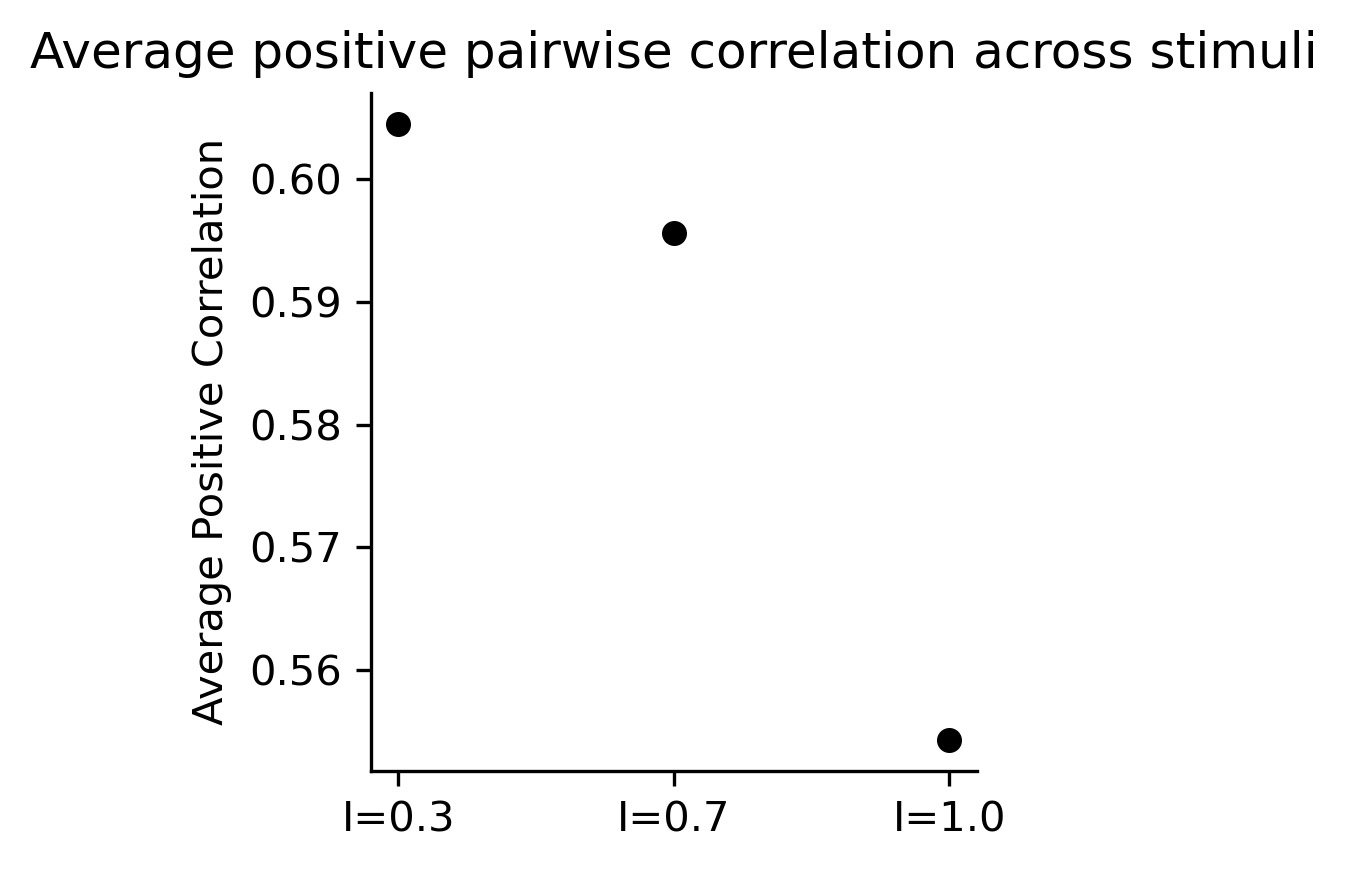

In [105]:
# Plot a bar plot of avg positive correlation
avg_pos_corrs = [pos_corrs_inh_1.mean(), pos_corrs_inh_2.mean(), pos_corrs_inh_3.mean()]
plt.figure(figsize=(3, 3), dpi=300)
# plt.bar(labels, avg_pos_corrs, color=['blue', 'orange', 'green'])
plt.plot([0, 1, 2], avg_pos_corrs, '.k', ms=10)
plt.xticks([0, 1, 2], labels)
plt.ylabel("Average Positive Correlation")
plt.title("Average positive pairwise correlation across stimuli")
plt.tight_layout()
plt.show()

In [ ]:
w